In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
import pandas as pd
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report
import numpy as np


In [4]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
x=df.drop(columns=["Outcome"])
y=df.Outcome

<Axes: >

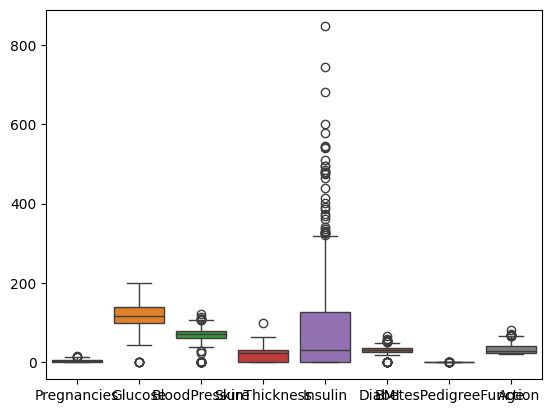

In [8]:
sns.boxplot(x)

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
main_pipeline = Pipeline(
  steps=[
    ('scaling',RobustScaler()),
    ('model',KNeighborsClassifier())
  ]
)
grid_search = GridSearchCV(
  estimator=main_pipeline,
  param_grid={
    'model__n_neighbors':[5,21,23,25,27],
    'model__metric':['euclidean','manhattan']
  },cv=20,
  verbose=1,
  scoring='f1')

In [12]:
np.sqrt(xtrain.shape[0])#(thumb rule)


# 5,21,23,25,27(always start with default value of n_neighbors = 5
#and then check for the best value of n_neighbors using GridSearchCV)

np.float64(24.779023386727733)

In [13]:
grid_search.fit(xtrain,ytrain)

Fitting 20 folds for each of 10 candidates, totalling 200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [5, 21, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",20
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_dig

In [14]:
grid_search.best_params_

{'model__metric': 'euclidean', 'model__n_neighbors': 21}

In [15]:
ytrain.value_counts

<bound method IndexOpsMixin.value_counts of 60     0
618    1
346    0
294    0
231    1
      ..
71     0
106    0
270    1
435    1
102    0
Name: Outcome, Length: 614, dtype: int64>

In [17]:
model=grid_search.best_estimator_
model.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaling', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"


In [20]:
results=grid_search.cv_results_
pd.DataFrame(results)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,...,split13_test_score,split14_test_score,split15_test_score,split16_test_score,split17_test_score,split18_test_score,split19_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004789,0.002249,0.004507,0.000960,euclidean,5,"{'model__metric': 'euclidean', 'model__n_neigh...",0.500000,0.555556,0.666667,...,0.470588,0.545455,0.631579,0.705882,0.631579,0.500000,0.700000,0.594778,0.096944,3
1,0.006254,0.006726,0.005124,0.001625,euclidean,21,"{'model__metric': 'euclidean', 'model__n_neigh...",0.400000,0.631579,0.470588,...,0.400000,0.526316,0.777778,0.705882,0.631579,0.500000,0.705882,0.613737,0.127488,1
2,0.005090,0.001200,0.004828,0.000796,euclidean,23,"{'model__metric': 'euclidean', 'model__n_neigh...",0.421053,0.631579,0.555556,...,0.400000,0.526316,0.705882,0.777778,0.631579,0.400000,0.750000,0.610624,0.123688,2
3,0.005316,0.001220,0.005544,0.000960,euclidean,25,"{'model__metric': 'euclidean', 'model__n_neigh...",0.444444,0.631579,0.470588,...,0.400000,0.250000,0.625000,0.705882,0.588235,0.428571,0.750000,0.583581,0.141653,6
4,0.005403,0.000744,0.005556,0.000902,euclidean,27,"{'model__metric': 'euclidean', 'model__n_neigh...",0.421053,0.588235,0.588235,...,0.400000,0.266667,0.625000,0.705882,0.588235,0.400000,0.750000,0.585423,0.145652,5
5,0.004938,0.001075,0.005391,0.001244,manhattan,5,"{'model__metric': 'manhattan', 'model__n_neigh...",0.476190,0.500000,0.695652,...,0.444444,0.500000,0.666667,0.823529,0.700000,0.555556,0.761905,0.585645,0.138784,4
6,0.004579,0.000900,0.004618,0.000930,manhattan,21,"{'model__metric': 'manhattan', 'model__n_neigh...",0.333333,0.588235,0.352941,...,0.400000,0.526316,0.705882,0.533333,0.631579,0.307692,0.588235,0.544968,0.133888,8
7,0.004924,0.001109,0.004967,0.000945,manhattan,23,"{'model__metric': 'manhattan', 'model__n_neigh...",0.333333,0.500000,0.352941,...,0.400000,0.444444,0.705882,0.625000,0.705882,0.307692,0.588235,0.546692,0.143010,7
8,0.005973,0.001269,0.006357,0.001475,manhattan,25,"{'model__metric': 'manhattan', 'model__n_neigh...",0.266667,0.588235,0.250000,...,0.400000,0.266667,0.625000,0.625000,0.666667,0.307692,0.666667,0.536416,0.171465,9
9,0.006067,0.001332,0.006698,0.001640,manhattan,27,"{'model__metric': 'manhattan', 'model__n_neigh...",0.266667,0.588235,0.250000,...,0.428571,0.266667,0.571429,0.625000,0.533333,0.307692,0.666667,0.513671,0.155262,10


In [21]:
pred_train=model.predict(xtrain)
pred_test=model.predict(xtest)

In [22]:
#training data
print('-------Training Data-------')
print(classification_report(ytrain,pred_train))
#testing data
print('-------Testing Data-------')
print(classification_report(ytest,pred_test))


-------Training Data-------
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       401
           1       0.79      0.56      0.66       213

    accuracy                           0.80       614
   macro avg       0.80      0.74      0.76       614
weighted avg       0.80      0.80      0.79       614

-------Testing Data-------
              precision    recall  f1-score   support

           0       0.75      0.85      0.80        99
           1       0.64      0.49      0.56        55

    accuracy                           0.72       154
   macro avg       0.70      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154

